In [55]:
import glob
import pandas as pd
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
SUBTASK = "subtask1"
FILE = f"./TRAIN_RELEASE_3SEP2025/train_{SUBTASK}.csv"


In [7]:
# load subtask1 data
df = pd.read_csv(FILE)
df.head()
    

,user_id,text_id,text,timestamp,collection_phase,is_words,valence,arousal
0,3,251,I ' ve been feeling just fine . Nice and relax...,2021-06-08 12:26:16,1,False,1.0,1.0
1,3,252,I ' ve been feeling pretty good . This is my l...,2021-06-09 13:41:40,1,False,0.0,1.0
2,3,253,Still feeling sick today and sneezing alot wit...,2021-06-11 15:13:48,1,False,1.0,1.0
3,3,254,I ' m still feeling kinda sickly but I powered...,2021-06-12 12:20:03,1,False,1.0,1.0
4,3,255,I ' m feeling so much better today ! Seems lik...,2021-06-13 14:54:41,1,False,2.0,1.0


In [15]:
df_feeling_words = df[df["is_words"]]
print(f"The feeling words instances consist of {len(df_feeling_words)/len(df)*100:.2f}% of the total")

The feeling words instances consist of 51.85% of the total


In [45]:
words = [w.strip().lower() for ws in df_feeling_words["text"] for w in ws.split(", ")]
tf = Counter(words)

# Convert to Markdown table
md_table = pd.DataFrame(sorted(tf.items(), key=lambda x: x[1], reverse=True), 
                        columns=["Feeling Word", "Count"]).to_markdown(index=False)

# Write to a markdown file
with open("./TRAIN_RELEASE_3SEP2025/feeling_word_frequency.md", "w", encoding="utf-8") as f:
    f.write("# Feeling Words Frequency in SubTask 1\n\n")
    f.write(md_table)
f.close()

In [35]:
print(len(tf.keys()))

861


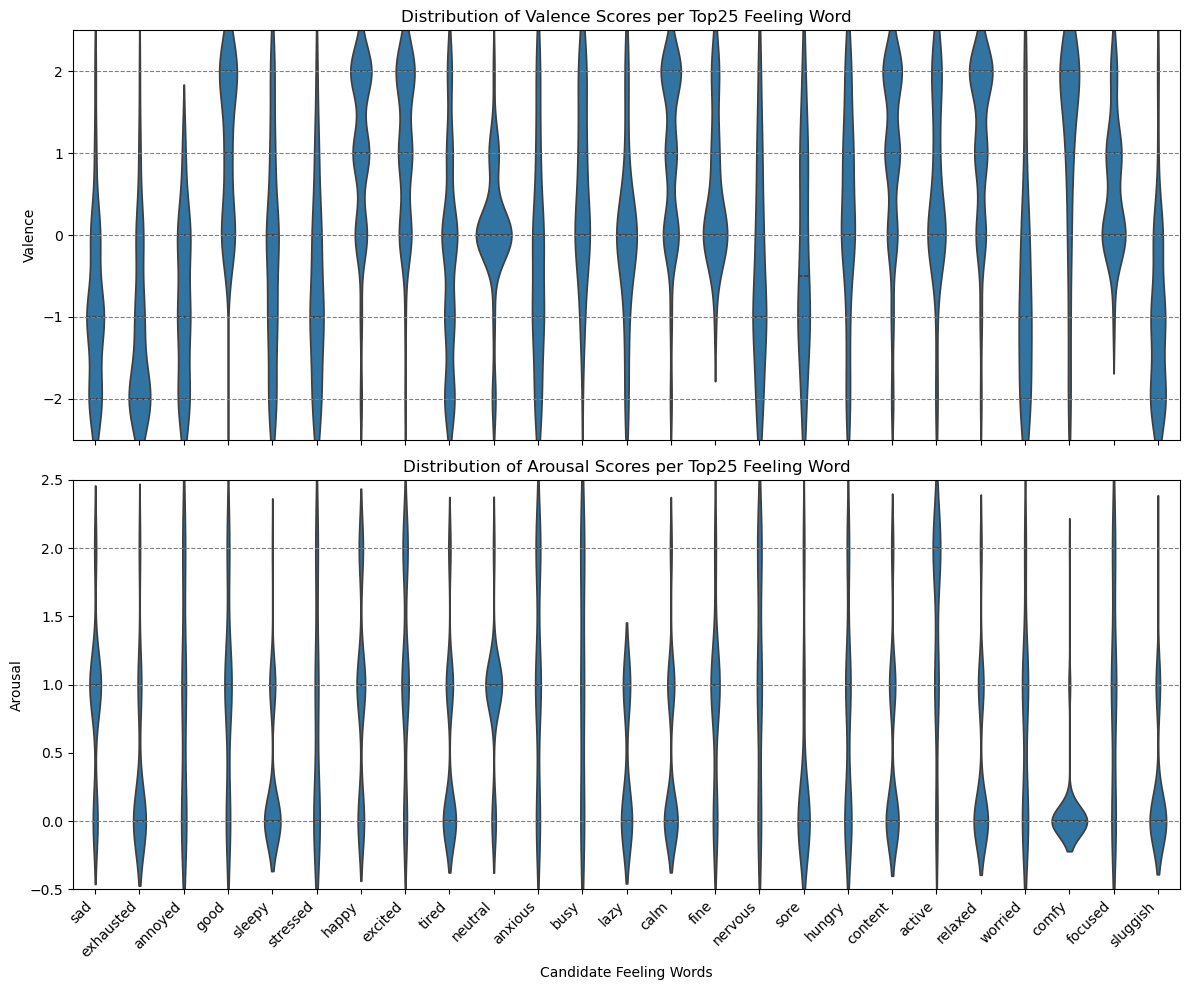

In [75]:
candidate_words = {k for k, _ in tf.most_common(25)}

# 1. Split and explode the text column into individual words
df_expanded = (
    df.assign(text=df_feeling_words['text'].str.split(", "))
      .explode("text")
)

# 2. Clean up (strip spaces and lowercase)
df_expanded["text"] = df_expanded["text"].str.strip().str.lower()


# 3. Filter rows where text ∈ candidate_words
df_filtered = df_expanded[df_expanded["text"].isin(candidate_words)].copy()

# 4. Preserve x-axis order
df_filtered["text"] = pd.Categorical(df_filtered["text"], categories=candidate_words, ordered=True)

# 5. Violin plot
# Create figure with 2 subplots (vertical layout)
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)  # share x-axis

# Violin plot for valence
sns.violinplot(
    data=df_filtered, 
    x="text", 
    y="valence", 
    order=candidate_words, 
    inner="quartile", 
    ax=axes[0]
)
axes[0].set_ylim(-2.5, 2.5)
axes[0].set_ylabel("Valence")
axes[0].set_title("Distribution of Valence Scores per Top25 Feeling Word")
# Add horizontal lines at -2, -1, 0, 1, 2
for y in [-2, -1, 0, 1, 2]:
    axes[0].axhline(y=y, color='gray', linestyle='--', linewidth=0.8)

# Violin plot for arousal
sns.violinplot(
    data=df_filtered, 
    x="text", 
    y="arousal", 
    order=candidate_words, 
    inner="quartile", 
    ax=axes[1]
)
axes[1].set_ylim(-0.5, 2.5)
axes[1].set_xlabel("Candidate Feeling Words")
axes[1].set_ylabel("Arousal")
axes[1].set_title("Distribution of Arousal Scores per Top25 Feeling Word")

# Add horizontal lines at 0, 1, 2
for y in [0, 1, 2]:
    axes[1].axhline(y=y, color='gray', linestyle='--', linewidth=0.8)

# Rotate x-axis labels for both subplots
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("./TRAIN_RELEASE_3SEP2025/dist_valence_arousal_by_top25_feeling_words.pdf")
plt.show()

In [105]:
train_files = glob.glob("./split/subtask1_train_cv*.csv")
test_files = glob.glob("./split/subtask1_test_cv*.csv")
def _load_csvs(files):
    dfs = []
    
    # 3. Loop over files, read each CSV, append to list
    for file in files:
        df = pd.read_csv(file)
        if 23 in df["user_id"]:
            print(file)
        dfs.append(df)
    
    # 4. Concatenate all DataFrames into one
    combined_df = pd.concat(dfs, ignore_index=True)
    combined_df = combined_df.drop_duplicates()
    return combined_df

train_df = _load_csvs(train_files)
test_df = _load_csvs(test_files)

./split/subtask1_train_cv1.csv
./split/subtask1_train_cv3.csv
./split/subtask1_train_cv2.csv
./split/subtask1_train_cv5.csv
./split/subtask1_train_cv4.csv
./split/subtask1_test_cv4.csv
./split/subtask1_test_cv5.csv
./split/subtask1_test_cv1.csv
./split/subtask1_test_cv2.csv
./split/subtask1_test_cv3.csv


In [109]:
[i for i in train_df["user_id"] if i not in test_df["user_id"]]

[]

In [101]:
23 in test_df["user_id"]

True

In [133]:
len(set(train_df["user_id"].tolist()) - set(test_df["user_id"].tolist()))

    

40

In [137]:
len(set(train_df["user_id"].tolist()+test_df["user_id"].tolist()))

137

In [139]:
40/137

0.291970802919708